# EDA: Vehicle Insurance Claim Fraud Detection

Exploratory data analysis on `fraud_oracle_cleaned.csv` for the LexisNexis fraud-scoring project.

In [64]:
!rm -rf LexisNexis-1A-detecting-fraudulent-insurance-claims
!git clone https://github.com/Break-Through-Tech/LexisNexis-1A-detecting-fraudulent-insurance-claims.git
%cd /content/LexisNexis-1A-detecting-fraudulent-insurance-claims

Cloning into 'LexisNexis-1A-detecting-fraudulent-insurance-claims'...
remote: Enumerating objects: 84, done.
remote: Counting objects: 100% (84/84), done.
remote: Compressing objects: 100% (82/82), done.
remote: Total 84 (delta 47), reused 3 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (84/84), 1.00 MiB | 3.62 MiB/s, done.
Resolving deltas: 100% (47/47), done.
/content/LexisNexis-1A-detecting-fraudulent-insurance-claims


In [65]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

TARGET = "FraudFound_P"

df = pd.read_csv("data/fraud_oracle_cleaned.csv")
df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy,Age_missing
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability,0
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision,0
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision,0
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability,0
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision,0


In [66]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, classification_report,
                             precision_recall_fscore_support)


train = df[df["Year"] <= 1995]
test  = df[df["Year"] == 1996]

def capture_rate(y_true, probs, top_frac):
    y_true = np.asarray(y_true)
    n_review = int(len(y_true) * top_frac)
    top_idx = np.argsort(probs)[::-1][:n_review]
    return y_true[top_idx].sum() / y_true.sum()

def make_model(X, class_weight=None):
    """Logistic regression pipeline; column types are inferred from X."""
    num = X.select_dtypes("number").columns.tolist()
    cat = X.select_dtypes(exclude="number").columns.tolist()
    return Pipeline([
        ("prep", ColumnTransformer([
            ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                              ("sc", StandardScaler())]), num),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat)])),
        ("clf", LogisticRegression(max_iter=1000, class_weight=class_weight)),
    ])

def evaluate(y, probs, preds):
    """Threshold metrics plus ranking metrics (what investigators actually use)."""
    y = np.asarray(y)
    p, r, f, _ = precision_recall_fscore_support(y, preds, average="binary",
                                                 zero_division=0)
    out = {"Precision (0.5 threshold)": p,
           "Recall (0.5 threshold)": r,
           "F1 (0.5 threshold)": f,
           "PR-AUC": average_precision_score(y, probs)}
    for frac in (0.10, 0.20):
        top = np.argsort(probs)[::-1][:int(len(y) * frac)]
        out[f"Precision @ top {frac:.0%}"] = y[top].mean()
        out[f"Fraud caught @ top {frac:.0%}"] = y[top].sum() / y.sum()
    return out

print(train.shape, test.shape)

(11336, 34) (4083, 34)


## 1. Basic metrics


Fraud is expected to be a rare class (~6%), which is why this project uses precision/recall/F1/PR-AUC instead of accuracy, a model that always predicts "not fraud" would already be ~94% accurate while catching zero fraud.

In [67]:
print("Rows, columns:", df.shape)
print("Missing values:", df.isna().sum().sum())
print("\nFraud counts:")
print(df[TARGET].value_counts())
print("\nFraud rate:", round(df[TARGET].mean(), 4))

Rows, columns: (15419, 34)
Missing values: 319

Fraud counts:
FraudFound_P
0    14496
1      923
Name: count, dtype: int64

Fraud rate: 0.0599


## 2. Class balance



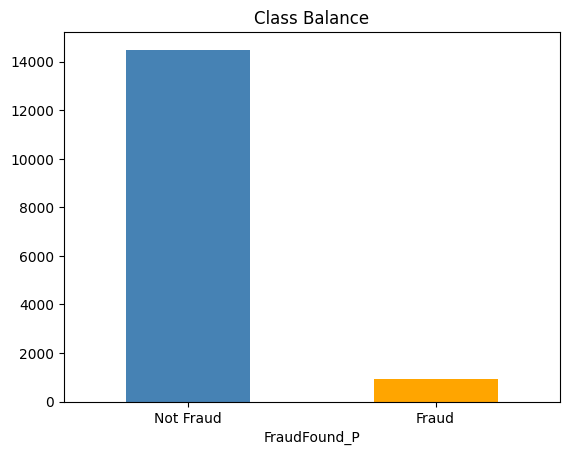

In [68]:
fig, ax = plt.subplots()
df[TARGET].value_counts().sort_index().plot(kind="bar", ax=ax, color=["steelblue", "orange"])
ax.set_xticklabels(["Not Fraud", "Fraud"], rotation=0)
ax.set_title("Class Balance")
plt.show()

## 3. Age distribution


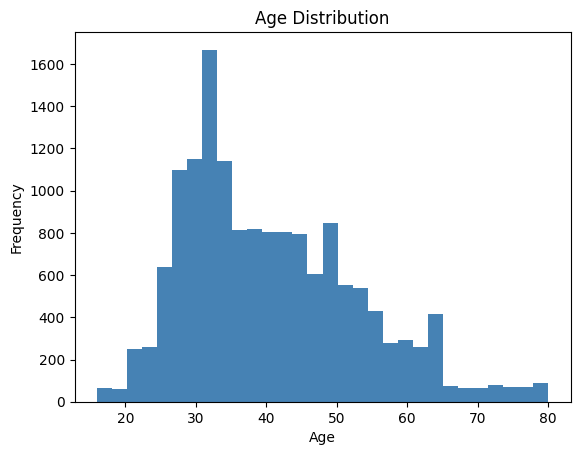

In [69]:
fig, ax = plt.subplots()
df["Age"].plot(kind="hist", bins=30, ax=ax, color="steelblue")
ax.set_title("Age Distribution")
ax.set_xlabel("Age")
plt.show()

## 4. Fraud rate by vehicle category



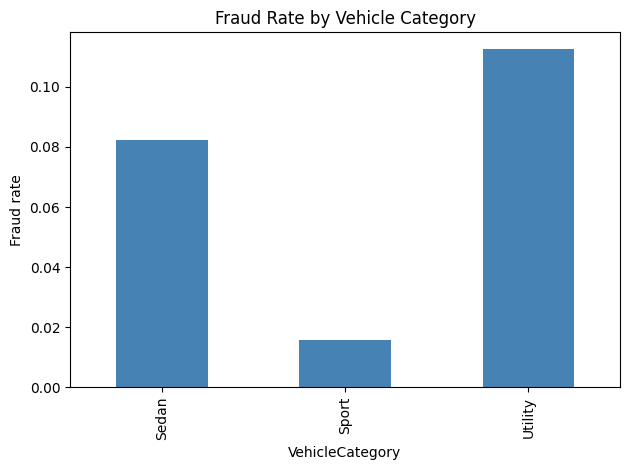

In [70]:
fig, ax = plt.subplots()
df.groupby("VehicleCategory")[TARGET].mean().plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Fraud Rate by Vehicle Category")
ax.set_ylabel("Fraud rate")
plt.tight_layout()
plt.show()

## 5. Fraud rate by fault

Third-party-fault claims have a noticeably lower fraud rate than policyholder-fault claims. This is intuitive: it's harder to fake fault that isn't yours. We check whether `Fault` also carries weight in the baseline model's coefficients in Task 5.

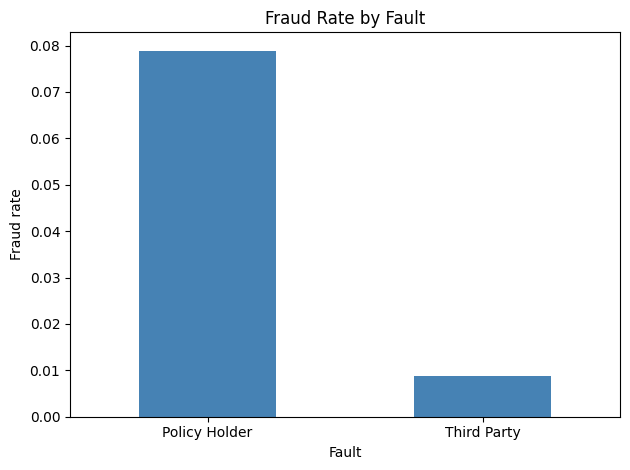

In [71]:
fig, ax = plt.subplots()
df.groupby("Fault")[TARGET].mean().plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Fraud Rate by Fault")
ax.set_ylabel("Fraud rate")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

## 6. Fraud rate by year (validating the temporal split)

The project requires a temporal hold-out split (train on earlier years, test on the most recent year) instead of random K-Fold, since the data spans 1994–1996. Before trusting that split, check that the fraud rate doesn't swing wildly year to year — a big jump would make training on the past and testing on 1996 unfair to the model.

Result: 6.7% → 5.8% → 5.2%, a gentle decline rather than a cliff, so the split is safe to use.

       mean  size
Year             
1994  0.067  6141
1995  0.058  5195
1996  0.052  4083


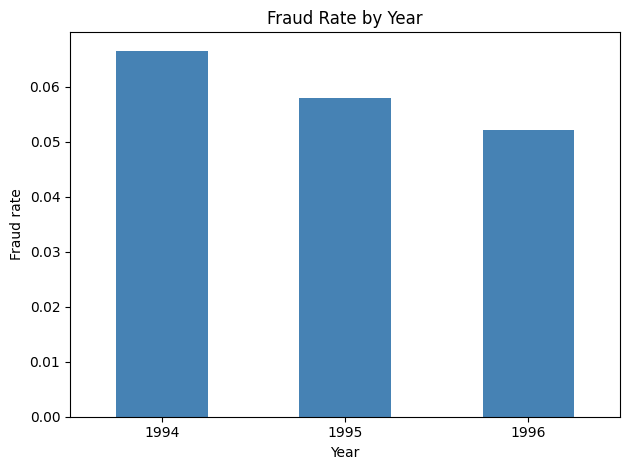

       mean  size
Year             
1994  0.067  6141
1995  0.058  5195
1996  0.052  4083


In [72]:
print(df.groupby("Year")[TARGET].agg(["mean", "size"]).round(3))
fig, ax = plt.subplots()
df.groupby("Year")[TARGET].mean().plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Fraud Rate by Year")
ax.set_ylabel("Fraud rate")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()
print(df.groupby("Year")[TARGET].agg(["mean", "size"]).round(3))

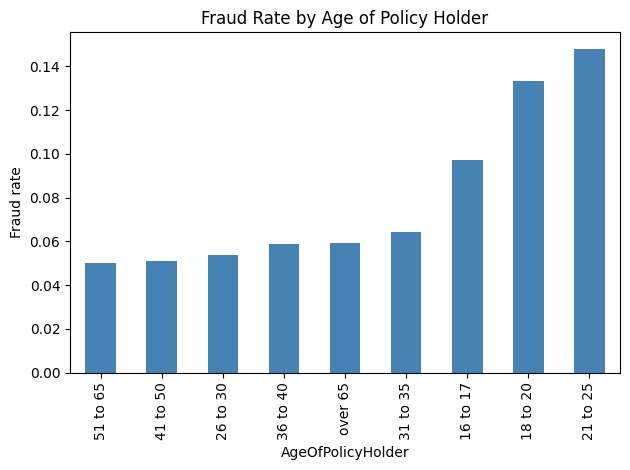

In [73]:
fig, ax = plt.subplots()
df.groupby("AgeOfPolicyHolder")[TARGET].mean().sort_values().plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Fraud Rate by Age of Policy Holder")
ax.set_ylabel("Fraud rate")
plt.tight_layout()
plt.show()

## 7. Fraud rate by policy type

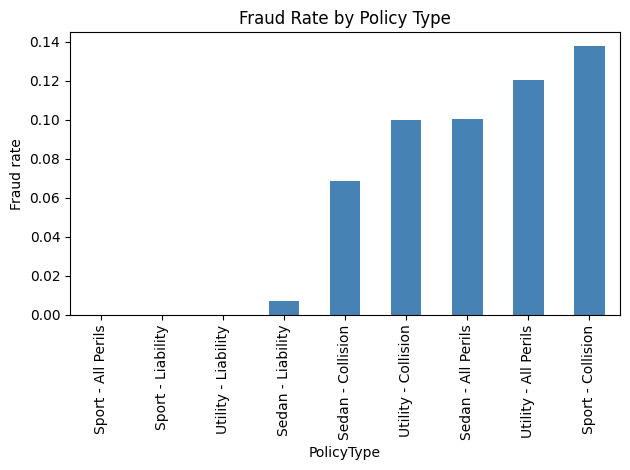

In [74]:
fig, ax = plt.subplots()
df.groupby("PolicyType")[TARGET].mean().sort_values().plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Fraud Rate by Policy Type")
ax.set_ylabel("Fraud rate")
plt.tight_layout()
plt.show()

## 8. Fraud rate by Accident Area

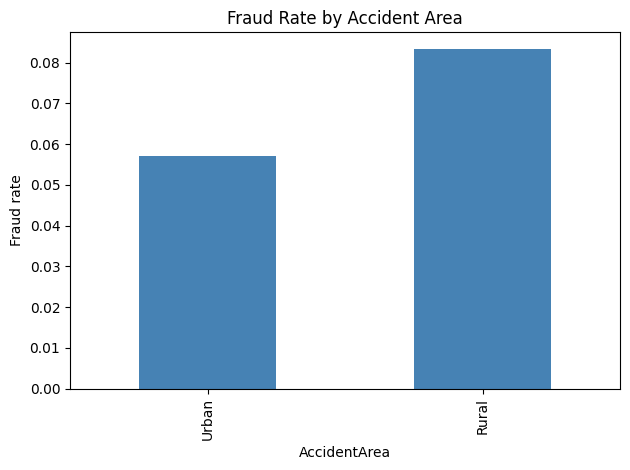

In [75]:
fig, ax = plt.subplots()
df.groupby("AccidentArea")[TARGET].mean().sort_values().plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Fraud Rate by Accident Area")
ax.set_ylabel("Fraud rate")
plt.tight_layout()
plt.show()

## 9. Fraud rate by Sex

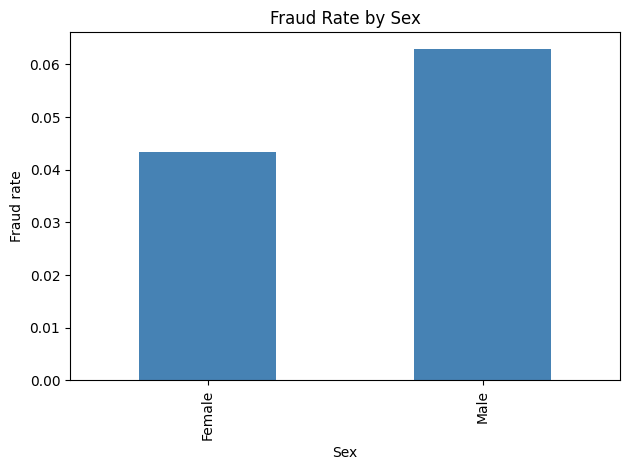

In [76]:
fig, ax = plt.subplots()
df.groupby("Sex")[TARGET].mean().sort_values().plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Fraud Rate by Sex")
ax.set_ylabel("Fraud rate")
plt.tight_layout()
plt.show()

**Sections 7–9 notes:** <one line each on what the Policy Type, Accident Area, and Sex plots show>.
`Sex` is not a leakage risk, but using it in an insurance model can raise fairness/regulatory questions. It's kept for the baseline and flagged for review before any production use.

In [77]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, classification_report,
                             f1_score, precision_score, recall_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

TARGET = "FraudFound_P"
train = df[df["Year"] <= 1995]
test  = df[df["Year"] == 1996]

def make_model(X, class_weight=None):
    num = X.select_dtypes("number").columns.tolist()
    cat = X.select_dtypes(exclude="number").columns.tolist()
    prep = ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("sc", StandardScaler())]), num),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("oh", OneHotEncoder(handle_unknown="ignore"))]), cat),
    ])
    return Pipeline([("prep", prep),
                     ("clf", LogisticRegression(max_iter=1000,
                                                class_weight=class_weight))])

def top_k(y_true, probs, frac):
    y_true = np.asarray(y_true)
    idx = np.argsort(probs)[::-1][:int(len(y_true) * frac)]
    hits = y_true[idx].sum()
    return hits / len(idx), hits / y_true.sum()

def evaluate(y_true, probs, preds):
    out = {
        "Precision (0.5 threshold)": precision_score(y_true, preds, zero_division=0),
        "Recall (0.5 threshold)":    recall_score(y_true, preds, zero_division=0),
        "F1 (0.5 threshold)":        f1_score(y_true, preds, zero_division=0),
        "PR-AUC": average_precision_score(y_true, probs),
    }
    for frac in (0.10, 0.20):
        p, c = top_k(y_true, probs, frac)
        out[f"Precision @ top {frac:.0%}"] = p
        out[f"Fraud caught @ top {frac:.0%}"] = c
    return out

In [78]:
# Task 3: Feature Leakage Audit
# Question: would we know this when the claim is first filed?
rows = [
    # Feature, Timing, Leakage risk, Decision, Reason
    ("Month",               "At filing", "No", "Keep", "Month of accident"),
    ("WeekOfMonth",         "At filing", "No", "Keep", "Week of accident"),
    ("DayOfWeek",           "At filing", "No", "Keep", "Day of accident"),
    ("MonthClaimed",        "At filing", "No", "Keep", "Recorded when the claim is filed"),
    ("WeekOfMonthClaimed",  "At filing", "No", "Keep", "Recorded when the claim is filed"),
    ("DayOfWeekClaimed",    "At filing", "No", "Keep", "Recorded when the claim is filed"),
    ("Make",                "At filing", "No", "Keep", "Vehicle attribute on the policy"),
    ("VehicleCategory",     "At filing", "No", "Keep", "Vehicle attribute on the policy"),
    ("VehiclePrice",        "At filing", "No", "Keep", "Vehicle attribute on the policy"),
    ("AgeOfVehicle",        "At filing", "No", "Keep", "Vehicle attribute on the policy"),
    ("NumberOfCars",        "At filing", "No", "Keep", "Policy attribute"),
    ("AccidentArea",        "At filing", "No", "Keep", "Reported by claimant"),
    ("Fault",               "At filing", "Low", "Keep", "Strong signal; confirm fault is reported at filing, not decided later"),
    ("Sex",                 "At filing", "No", "Keep (review)", "Not leakage; fairness review before production"),
    ("MaritalStatus",       "At filing", "No", "Keep", "Policyholder attribute"),
    ("Age",                 "At filing", "No", "Keep", "Policyholder attribute (0 treated as missing)"),
    ("Age_missing",         "At filing", "No", "Keep", "Flag for rows where Age was not recorded (Task 2)"),
    ("AgeOfPolicyHolder",   "At filing", "No", "Keep", "Binned age; overlaps with Age"),
    ("PolicyType",          "At filing", "No", "Keep", "Policy attribute"),
    ("BasePolicy",          "At filing", "No", "Keep", "Policy attribute"),
    ("Deductible",          "At filing", "No", "Keep", "Policy attribute"),
    ("DriverRating",        "At filing", "No", "Keep", "Policy attribute; confirm calculated before this claim"),
    ("AgentType",           "At filing", "No", "Keep", "Policy attribute"),
    ("Days_Policy_Accident","At filing", "No", "Keep", "Policy start to accident date"),
    ("Days_Policy_Claim",   "At filing", "No", "Keep", "Policy start to claim date"),
    ("PastNumberOfClaims",  "At filing", "Low", "Keep", "Prior history; confirm it excludes the current claim"),
    ("PoliceReportFiled",   "Unclear (no timestamps)", "Possible", "Keep (pending advisor)",
        "Likely reported at intake; timing assumed, confirm with advisor"),
    ("WitnessPresent",      "Unclear (no timestamps)", "Possible", "Keep (pending advisor)",
        "Likely in the initial accident report; timing assumed, confirm with advisor"),
    ("AddressChange_Claim", "Unclear (no timestamps)", "Possible", "Keep (pending advisor)",
        "Historical address info; timing assumed, confirm with advisor"),
    ("NumberOfSuppliments", "Later in claim lifecycle", "Yes", "Drop",
        "Supplements are added as the claim is processed"),
    ("PolicyNumber",        "At filing", "No", "Drop", "Identifier; also encodes time (corr with Year ~0.94)"),
    ("RepNumber",           "At filing", "No", "Drop", "Identifier; may reflect operational assignment"),
    ("Year",                "At filing", "No", "Drop as feature", "Used for the temporal split only"),
]
audit = pd.DataFrame(rows, columns=["Feature", "Timing", "Leakage Risk", "Decision", "Reason"])

# Guard: every column except the target must be audited
unaudited = set(df.columns) - {TARGET} - set(audit["Feature"])
assert not unaudited, f"Not audited: {unaudited}"
pd.set_option("display.max_colwidth", None)
display(audit)

SAFE_FEATURES = audit.loc[~audit["Decision"].str.startswith("Drop"), "Feature"].tolist()
DROP_COLS     = audit.loc[audit["Decision"].str.startswith("Drop"), "Feature"].tolist()
KEPT_PENDING  = ["PoliceReportFiled", "WitnessPresent", "AddressChange_Claim"]
print(f"Final safe feature set ({len(SAFE_FEATURES)}):", SAFE_FEATURES)
print("Dropped:", DROP_COLS)

# Evidence: how much do the pending / dropped features change results?
comparison = {}
for name, feats in {
    "Without the 3 pending features": [f for f in SAFE_FEATURES if f not in KEPT_PENDING],
    "Final set (3 pending kept)":     SAFE_FEATURES,
    "Final + NumberOfSuppliments":    SAFE_FEATURES + ["NumberOfSuppliments"],
}.items():
    X_tr, X_te = train[feats].copy(), test[feats].copy()
    for X in (X_tr, X_te):
        if "Age_missing" in X:
            X["Age_missing"] = X["Age_missing"].astype(int)
    m = make_model(X_tr).fit(X_tr, train[TARGET])
    comparison[name] = evaluate(test[TARGET], m.predict_proba(X_te)[:, 1], m.predict(X_te))

display(pd.DataFrame(comparison).T[["PR-AUC", "Fraud caught @ top 10%",
                                    "Fraud caught @ top 20%"]].round(3))

,Feature,Timing,Leakage Risk,Decision,Reason
0,Month,At filing,No,Keep,Month of accident
1,WeekOfMonth,At filing,No,Keep,Week of accident
2,DayOfWeek,At filing,No,Keep,Day of accident
3,MonthClaimed,At filing,No,Keep,Recorded when the claim is filed
4,WeekOfMonthClaimed,At filing,No,Keep,Recorded when the claim is filed
5,DayOfWeekClaimed,At filing,No,Keep,Recorded when the claim is filed
6,Make,At filing,No,Keep,Vehicle attribute on the policy
7,VehicleCategory,At filing,No,Keep,Vehicle attribute on the policy
8,VehiclePrice,At filing,No,Keep,Vehicle attribute on the policy
9,AgeOfVehicle,At filing,No,Keep,Vehicle attribute on the policy


Final safe feature set (29): ['Month', 'WeekOfMonth', 'DayOfWeek', 'MonthClaimed', 'WeekOfMonthClaimed', 'DayOfWeekClaimed', 'Make', 'VehicleCategory', 'VehiclePrice', 'AgeOfVehicle', 'NumberOfCars', 'AccidentArea', 'Fault', 'Sex', 'MaritalStatus', 'Age', 'Age_missing', 'AgeOfPolicyHolder', 'PolicyType', 'BasePolicy', 'Deductible', 'DriverRating', 'AgentType', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'PoliceReportFiled', 'WitnessPresent', 'AddressChange_Claim']
Dropped: ['NumberOfSuppliments', 'PolicyNumber', 'RepNumber', 'Year']


,PR-AUC,Fraud caught @ top 10%,Fraud caught @ top 20%
Without the 3 pending features,0.095,0.160,0.347
Final set (3 pending kept),0.101,0.164,0.333
Final + NumberOfSuppliments,0.099,0.164,0.324


**Audit conclusion.** All 32 columns were reviewed. The four flagged columns are dropped because they may not exist at first notice of loss; identifiers and `Year` are dropped as features. Adding the flagged features back barely changes performance (PR-AUC ~0.100 vs ~0.095, and top-20% capture is actually lower), so excluding them costs almost nothing and removes the leakage risk.

In [79]:
# Task 5: Baseline Logistic Regression (temporal hold-out: train 1994-95, test 1996)
X_train, y_train = train[SAFE_FEATURES], train[TARGET]
X_test,  y_test  = test[SAFE_FEATURES],  test[TARGET]

models = {"Baseline LogReg": make_model(X_train),
          "Balanced LogReg": make_model(X_train, class_weight="balanced")}

scores = {}
for name, m in models.items():
    m.fit(X_train, y_train)
    scores[name] = evaluate(y_test, m.predict_proba(X_test)[:, 1], m.predict(X_test))

base_rate = y_test.mean()
scores["Random guess"] = {
    "Precision (0.5 threshold)": np.nan, "Recall (0.5 threshold)": np.nan,
    "F1 (0.5 threshold)": np.nan, "PR-AUC": base_rate,
    "Precision @ top 10%": base_rate, "Fraud caught @ top 10%": 0.10,
    "Precision @ top 20%": base_rate, "Fraud caught @ top 20%": 0.20,
}
results = pd.DataFrame(scores).round(3)
display(results)

print("Balanced LogReg, full report at 0.5 threshold:")
print(classification_report(y_test, models["Balanced LogReg"].predict(X_test),
                            digits=3, zero_division=0))

,Baseline LogReg,Balanced LogReg,Random guess
Precision (0.5 threshold),0.333,0.101,NaN
Recall (0.5 threshold),0.005,0.676,NaN
F1 (0.5 threshold),0.009,0.176,NaN
PR-AUC,0.101,0.096,0.052
Precision @ top 10%,0.086,0.076,0.052
Fraud caught @ top 10%,0.164,0.146,0.100
Precision @ top 20%,0.087,0.089,0.052
Fraud caught @ top 20%,0.333,0.343,0.200


Balanced LogReg, full report at 0.5 threshold:
              precision    recall  f1-score   support

           0      0.974     0.670     0.794      3870
           1      0.101     0.676     0.176       213

    accuracy                          0.670      4083
   macro avg      0.538     0.673     0.485      4083
weighted avg      0.929     0.670     0.762      4083



In [80]:
# Top drivers in the balanced baseline
m = models["Balanced LogReg"]
coefs = pd.Series(m.named_steps["clf"].coef_[0],
                  index=m.named_steps["prep"].get_feature_names_out()).sort_values()
print("Pushes toward NOT fraud:"); display(coefs.head(10).round(3))
print("Pushes toward fraud:");     display(coefs.tail(10).round(3))

Pushes toward NOT fraud:


,0
cat__Fault_Third Party,-1.916
cat__BasePolicy_Liability,-1.305
cat__AddressChange_Claim_no change,-1.236
cat__AddressChange_Claim_4 to 8 years,-1.192
cat__PolicyType_Sport - All Perils,-1.144
cat__Make_Dodge,-1.103
cat__Days_Policy_Accident_8 to 15,-0.928
cat__DayOfWeekClaimed_Sunday,-0.905
cat__AddressChange_Claim_1 year,-0.888
cat__PolicyType_Utility - Liability,-0.875


Pushes toward fraud:


,0
cat__Make_Mercedes,0.559
cat__Days_Policy_Claim_8 to 15,0.734
cat__Make_Mercury,0.809
cat__PolicyType_Sedan - All Perils,0.827
cat__AgeOfVehicle_4 years,0.836
cat__BasePolicy_Collision,0.840
cat__Make_Acura,0.906
cat__PolicyType_Sport - Collision,1.151
cat__Fault_Policy Holder,1.678
cat__AddressChange_Claim_2 to 3 years,2.519


In [81]:
print(df.shape)
print(train.shape, test.shape)

(15419, 34)
(11336, 34) (4083, 34)


## Summary of Task 4

> Add blockquote



- Data is clean (no missing values) and the class imbalance is real (~6% fraud) — accuracy is not a usable metric.
- `VehicleCategory` and `Fault` carry genuine pre-investigation signal and are safe to keep.
- Fraud rate is stable enough across 1994–1996 to justify a temporal train/test split.


**Leakage Audit Conclusion**
- **Dropped:** NumberOfSuppliments (accumulates after filing), PolicyNumber and RepNumber (identifiers; PolicyNumber also encodes time).
- **Split only:** Year. **Target:** FraudFound_P.
- **Kept, pending advisor confirmation:** PoliceReportFiled, WitnessPresent, AddressChange_Claim. The dataset has no timestamps, so timing is assumed from field definitions.
- **Final feature set:** 29 columns.
- The comparison table shows how much the pending features change results. If the advisor says they are recorded after filing, we drop them and rerun.